In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import sys
import os

# Get the parent directory and add it to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import dem
from dem.models.components.mlp import MyMLPDualOutput
from dem.energies.gmm_energy import GMM

/network/scratch/b/bosejoey/micromamba/envs/dem/lib/python3.10/site-packages/torchmetrics/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:

from dem.models.components.clipper import Clipper
from dem.models.components.noise_schedules import LinearNoiseSchedule
from dem.energies.base_prior import Prior
from dem.utils.smc_utils import systematic_resample, stratified_resample, multinomial_resample

beta = torch.tensor(0.2).to(device)
noise_schedule = LinearNoiseSchedule(beta)
clipper = Clipper(
    should_clip_scores=False, should_clip_log_rewards=False, max_score_norm=50
)

prior = Prior(dim=2, device=device, scale = noise_schedule.h(1) ** 0.5)

In [5]:
import abc

class Schedule_base(metaclass=abc.ABCMeta):
    """Abstract base class from which all log densities should inherit."""

    def __init__(self):
        pass

    def __call__(self, x):
        outf = self.tt(x)
        doutf = self.dtt(x)
        
        return outf, doutf

    @abc.abstractmethod
    def tt(self, x): 
        pass

    @abc.abstractmethod
    def dtt(self, x): 
        pass

class CosSchedule(Schedule_base):
    def __init__(self):
        super().__init__()
    def tt(self,t):
        out = 0.5*(1.0-torch.cos(torch.pi*t))
        return out

    def dtt(self,t):
        out = (0.5*torch.pi*torch.sin(torch.pi*t))
        return out

class LinearSchedule(Schedule_base):
    def __init__(self):
        super().__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def tt(self, t):
        out = t 
        return out

    def dtt(self, t):
        out = torch.tensor(1.0).to(self.device)
        return out

In [6]:
import torch
from torch.autograd.functional import jacobian

def get_resampling_function(name):
    """
    Given a string name, return the corresponding resampling function.
    Supported names: 'systematic', 'stratified'
    """
    # Local imports to avoid import issues in notebook cells
    from dem.utils.smc_utils import systematic_resample, stratified_resample

    name = name.lower()
    if name in ['systematic', 'systematic_resample']:
        return systematic_resample
    elif name in ['stratified', 'stratified_resample']:
        return stratified_resample
    else:
        return multinomial_resample


class ReverseODE(torch.nn.Module):
    def __init__(self, drift, noise_schedule, prior, target, clipper, schedule, resample_threshold=0.7, resampling_method=None):
        super().__init__()
        self.drift = drift
        self.noise_schedule = noise_schedule
        self.prior = prior
        self.target = target
        self.clipper = clipper
        self.schedule = schedule
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.resample_threshold = resample_threshold
        self.resampling_method = get_resampling_function(resampling_method)
    
    def f(self, t, x):
        with torch.enable_grad():
            if t.dim() == 0:
                # repeat the same time for all points if we have a scalar time
                t = t * torch.ones(x.shape[0]).to(device)
            
            dx, weight = self.drift(t, x)
            return dx, weight
    
    def ess(self, wt):
        return torch.mean(torch.exp(wt))**2 / torch.mean(torch.exp(2*wt))
    
    def resample(self, samples, weights):
        # Check if weights are blowing up (using effective sample size as a metric)
        # Calculate effective sample size
        probs = torch.softmax(weights, dim=0)
        
        ess = self.ess(weights)
        print("ESS %f" % (ess))
        # Only resample if effective sample size is above threshold (e.g., 0.5)
        # This prevents resampling when weights are degenerate
        if ess < self.resample_threshold:
            print("ESS %f, Triggering resampling" % (ess))
            # Perform importance sampling resampling
            # Sample indices based on weights
            indices = self.resampling_method(probs)
           
            # Resample the final particles based on the sampled indices
            resampled_samples = samples[indices]
            weights = torch.zeros_like(weights)
        else:
            resampled_samples = samples
            weights = weights

        return resampled_samples, weights
    
    def euler_step(self, t, x, w, dt):
        drift, weight = self.f(t, x) 
        x = x + drift * dt
        w = w + weight * dt
        return x, w
    
    def sample(self, x0, dt, end_time, device=None, num_samples=None, compute_weight=False):
        """
        Sample from the ODE using Euler method.
        
        Args:
            x0: initial positions
            num_steps: number of integration steps
            dt: time step size
            device: device to run on
            
        Returns:
            samples: trajectory of samples
        """

        if device is None:
            device = x0.device
        
        if x0 is None:
            x = self.prior.sample(num_samples)
        else:
            x = x0

        samples = [x]
        w = torch.zeros(x.shape[0]).to(self.device)
        weights = [w]
        start_time = torch.tensor(0.0).to(self.device)
        delta = end_time - start_time
        num_integration_steps = int(torch.abs(delta) / dt)
        times = torch.linspace(start_time, end_time, num_integration_steps + 1, device=x.device)[:-1]
       
        for t in times:
            x, w = self.euler_step(t, x, w, dt)
            if compute_weight:
                x, w = self.resample(x, w)
                weights.append(w)
            samples.append(x)
        
        return torch.stack(samples)


class LangevinSDE(torch.nn.Module):
    """
    Langevin SDE implementation for sampling from energy functions.
    
    The Langevin SDE is given by:
    dx = -∇E(x)dt + √(2β) dW
    
    where E(x) is the energy function, β is the inverse temperature,
    and W is a Wiener process.
    """
    
    def __init__(self, beta=1.0, schedule=None, target=None, prior=None, vel=None, clipper=None, resample_threshold=0.98, resampling_method='systematic'):
        super().__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.beta = torch.tensor(beta).to(self.device)
        self.schedule = schedule
        self.target = target
        self.prior = prior
        self.vel = vel
        self.clipper = clipper
        self.resample_threshold = resample_threshold
        self.resampling_method = get_resampling_function(resampling_method)
    
    def f(self, t, x):
        """
        Drift term: f(t, x) = -∇E(x)
        
        Args:
            t: time (not used in Langevin dynamics)
            x: current position
            
        Returns:
            drift: -∇E(x)
        """
        
        with torch.enable_grad():
            outf, doutf = self.schedule(t)
            x.requires_grad_(True)
            energy_interpolation = outf * self.target(x) + (1-outf) * self.prior.log_prob(x)
            nabla_Ht = torch.autograd.grad(energy_interpolation.sum(), x, create_graph=True)[0]
            nabla_Ht = self.clipper.clip_scores(nabla_Ht)
            drift = self.beta * nabla_Ht
            if self.vel is not None:
                transport_drift = self.vel(t, x)[0]
            else:
                transport_drift = torch.zeros_like(x)
        return drift + transport_drift
    
    def g(self, x):
        """
        Diffusion term: g(t, x) = √(2β)
        
        Args:
            t: time (not used in Langevin dynamics)
            x: current position
            
        Returns:
            diffusion: √(2β) * ones_like(x)
        """
        diffusion = torch.sqrt(2.0 * self.beta) * torch.ones_like(x)
        return diffusion
    
    def divergence(self,t, x, vectorfield):
        # compute the divergence of the flow field
        def _func_sum(t_in, x_in):
            return vectorfield(t_in, x_in)[0].sum(dim=0) # sum over the batches
        out=jacobian(_func_sum, (t, x),create_graph =True,vectorize=True)
        spatial_grad = out[1]
        div = spatial_grad.diagonal(offset=0, dim1=-1, dim2=-3).sum(-1)
        return div

    def euler_maruyama_step(self, t, x, dt):
        t = t * torch.ones(x.shape[0]).to(self.device)
        drift = self.f(t, x)
        diffusion = self.g(x)
        dW = torch.randn_like(x) * torch.sqrt(dt)
        x = x + drift * dt + diffusion * dW
        return x
    
    def energy_interpolation(self, t, x):
        with torch.enable_grad():
            t = t * torch.ones(x.shape[0]).to(self.device)
            x.requires_grad_(True)
            outf, doutf = self.schedule(t)
            logtarget = self.target(x)
            logprior = self.prior.log_prob(x)
            energy_interpolation = outf * logtarget + (1-outf) * logprior
            return energy_interpolation.squeeze()
    
    def ess(self, wt):
        return torch.mean(torch.exp(wt))**2 / torch.mean(torch.exp(2*wt))
    
    def log_weight_step(self, w, x, t, dt):
        if self.vel is not None:
            with torch.enable_grad():
                t = t * torch.ones(x.shape[0]).to(self.device)
                x.requires_grad_(True)
                outf, doutf = self.schedule(t)
                logtarget = self.target(x)
                dlogtarget = -1 * torch.autograd.grad(logtarget.sum(), x, create_graph=True)[0]
                logprior = self.prior.log_prob(x)
                dlogprior = - 1* torch.autograd.grad(logprior.sum(), x, create_graph=True)[0]
                score = outf[:, None] * dlogtarget + (1-outf[:, None]) * dlogprior
                score = self.clipper.clip_scores(score)  
                partial_Ht = - (doutf * logtarget  - doutf * logprior)
                vel  = self.vel(t, x)[0]
                div = self.divergence(t, x, self.vel).detach()
                inner_prod = (score*vel).sum(axis=1)
                dw = div - inner_prod - partial_Ht
                
                w = w + dw*dt
                return w
        else:
            return w
    
    def resample(self, samples, weights):
        # Check if weights are blowing up (using effective sample size as a metric)
        # Calculate effective sample size
        ess = self.ess(weights)
        
        # Only resample if effective sample size is above threshold (e.g., 0.5)
        # This prevents resampling when weights are degenerate
        if ess < self.resample_threshold:
            # Convert weights to probabilities (normalize)
            print("ESS %f, Triggering resampling" % (ess))
            probs = torch.softmax(weights, dim=0)
            
            # Perform importance sampling resampling
            # Sample indices based on weights
            indices = self.resampling_method(probs)
            
            # Resample the final particles based on the sampled indices
            resampled_samples = samples[indices]
            weights = torch.zeros_like(weights)
        else:
            resampled_samples = samples
            weights = weights

        return resampled_samples, weights
    
    def sample(self, x0, dt, end_time, device=None, num_samples=None, resample=False):
        """
        Sample from the Langevin SDE using Euler-Maruyama method.
        
        Args:
            x0: initial positions
            num_steps: number of integration steps
            dt: time step size
            device: device to run on
            
        Returns:
            samples: trajectory of samples
        """

        if device is None:
            device = x0.device
        
        if x0 is None:
            x = self.prior.sample(num_samples)
        else:
            x = x0

        samples = [x]
        w = torch.zeros(x.shape[0]).to(self.device)
        weights = [w]
        start_time = torch.tensor(0.0).to(self.device)
        delta = end_time - start_time
        num_integration_steps = int(torch.abs(delta) / dt)
        times = torch.linspace(start_time, end_time, num_integration_steps + 1, device=x.device)[:-1]
       
        for t in times:
            x = self.euler_maruyama_step(t, x, dt)
            w = self.log_weight_step(w, x, t, dt)
            if resample:
                x, w = self.resample(x, w)

            weights.append(w)
            samples.append(x)
        
        return torch.stack(samples).detach(), torch.stack(weights).detach()

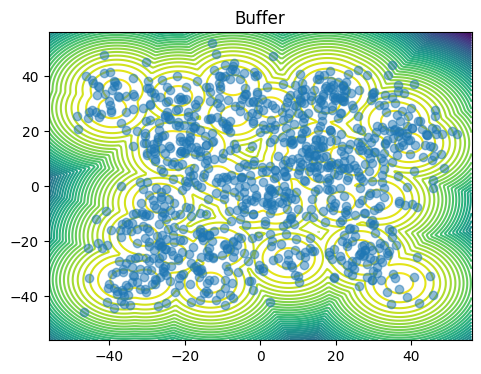

In [7]:
clipper = Clipper(
    should_clip_scores=False, should_clip_log_rewards=False, max_score_norm=50
)
target = GMM(dimensionality=2,
             n_mixes=40,
             loc_scaling= 40,
             log_var_scaling=1.0,
             device=device,
             should_unnormalize=True)
weighted = False
schedule = LinearSchedule()
langevin_sde= LangevinSDE(beta=1.0, prior=prior, target=target, clipper=clipper, schedule=schedule)

dt = torch.tensor(1.0 / 256).to(device)
t_init,t_end = torch.tensor(0.0).to(device), torch.tensor(1.0).to(device)
samples, _ = langevin_sde.sample(x0=None, dt=dt, end_time=t_end, device=device, num_samples=1_000, resample=False)
samples_energy = target(samples[-1])
target.get_dataset_fig(target.unnormalize(samples[-1]))
plt.show()


In [8]:
def divergence(t, x, vectorfield):
    # compute the divergence of the flow field
    def _func_sum(t_in, x_in):
        return vectorfield(t_in, x_in)[0].sum(dim=0) # sum over the batches
    out=jacobian(_func_sum, (t, x),create_graph =True,vectorize=True)
    spatial_grad = out[1]
    div = spatial_grad.diagonal(offset=0, dim1=-1, dim2=-3).sum(-1)
    return div

def compute_wfr_loss(pts, x, t, schedule, target, prior, vectorfield, lagrange_multiplier=1.0, compute_kinetic_energy=False):
    outf, doutf = schedule(t)
    x.requires_grad_(True)
    logtarget = target(x)
    dlogtarget = -1 * torch.autograd.grad(logtarget.sum(), x, create_graph=True)[0]
    logprior = prior.log_prob(x)
    dlogprior = - 1* torch.autograd.grad(logprior.sum(), x, create_graph=True)[0]
    score = outf * dlogtarget + (1-outf) * dlogprior
    score = clipper.clip_scores(score)  

    t_repeat = t.repeat(x.shape[0], 1)
    vel, weights = vectorfield(t_repeat, x)
    div = divergence(t_repeat, x, vectorfield).detach()
    inner_prod = (score*vel).sum(axis=1)
    partial_Ht = - (doutf * logtarget  - doutf * logprior)
    terms = div - inner_prod - partial_Ht

    weights_term = weights + weights.mean()
    terms = terms - weights_term

    if compute_kinetic_energy:
        kinetic_energy = kinetic_energy_loss(vel) + (weights**2).sum()
        loss = lagrange_multiplier * (terms).pow(2) +  0.5 * kinetic_energy
    else:
        loss = (terms).pow(2)
    if pts is not None:
        loss = loss * pts
    return loss

def generate_samples_ode(reverse_ode, num_samples, resample=False):
    x = prior.sample(num_samples)
    delta = t_end - t_init
    num_integration_steps = int(torch.abs(delta) / dt)
    times = torch.linspace(t_init, t_end, num_integration_steps + 1, device=device)[:-1]

    samples = [x]
    w = torch.zeros(x.shape[0], device=device)
    weights = [w]

    for t in times:
        drift, weight = reverse_ode.f(t, x)
        x = x + drift * dt
        w = w + weight * dt
        if resample and t > 0.9:
            x, w = reverse_ode.resample(x, w)
        samples.append(x)
        weights.append(w)

    return x

def kinetic_energy_loss(vel):
    """
    Computes the mean kinetic energy of the vectorfield at points x and time t.
    Kinetic energy is defined as 0.5 * ||v||^2, where v is the vectorfield output.
    """
    kinetic_energy = 0.5 * (vel ** 2).sum(dim=1)
    return kinetic_energy.mean()


All parameters on CUDA: True


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0 | Time 0.000000 | Loss 3236.943848
Epoch 0 | Time 0.003906 | Loss 3919.704102
Epoch 0 | Time 0.007812 | Loss 3544.109863
Epoch 0 | Time 0.011719 | Loss 2903.194092
Epoch 0 | Time 0.015625 | Loss 2376.313477
Epoch 0 | Time 0.019531 | Loss 1648.667969
Epoch 0 | Time 0.023438 | Loss 1068.238159
Epoch 0 | Time 0.027344 | Loss 909.214661
Epoch 0 | Time 0.031250 | Loss 713.051208
Epoch 0 | Time 0.035156 | Loss 547.948914
Epoch 0 | Time 0.039062 | Loss 424.155426
Epoch 0 | Time 0.042969 | Loss 405.632080
Epoch 0 | Time 0.046875 | Loss 390.262634
Epoch 0 | Time 0.050781 | Loss 359.535858
Epoch 0 | Time 0.054688 | Loss 387.774048
Epoch 0 | Time 0.058594 | Loss 378.965698
Epoch 0 | Time 0.062500 | Loss 373.578400
Epoch 0 | Time 0.066406 | Loss 383.039001
Epoch 0 | Time 0.070312 | Loss 398.008484
Epoch 0 | Time 0.074219 | Loss 403.762817
Epoch 0 | Time 0.078125 | Loss 411.219299
Epoch 0 | Time 0.082031 | Loss 356.638977
Epoch 0 | Time 0.085938 | Loss 341.958984
Epoch 0 | Time 0.089844 | L

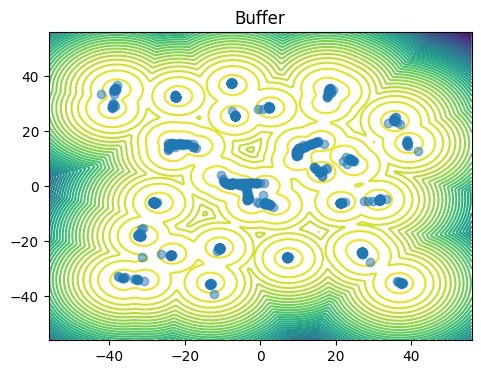

  1%|          | 1/100 [00:13<22:41, 13.75s/it]

ESS 0.969683, Triggering resampling
ESS 0.976690, Triggering resampling
ESS 0.979396, Triggering resampling
ESS 0.979847, Triggering resampling
ESS 0.979944, Triggering resampling
ESS 0.979600, Triggering resampling
ESS 0.979708, Triggering resampling
ESS 0.979564, Triggering resampling
ESS 0.979485, Triggering resampling
ESS 0.979180, Triggering resampling
ESS 0.979995, Triggering resampling
Epoch 1 | Time 0.000000 | Loss 3.016669
Epoch 1 | Time 0.003906 | Loss 1.353975
Epoch 1 | Time 0.007812 | Loss 0.739025
Epoch 1 | Time 0.011719 | Loss 0.530343
Epoch 1 | Time 0.015625 | Loss 0.447327
Epoch 1 | Time 0.019531 | Loss 0.394653
Epoch 1 | Time 0.023438 | Loss 0.357393
Epoch 1 | Time 0.027344 | Loss 0.331962
Epoch 1 | Time 0.031250 | Loss 0.321268
Epoch 1 | Time 0.035156 | Loss 0.296545
Epoch 1 | Time 0.039062 | Loss 0.271835
Epoch 1 | Time 0.042969 | Loss 0.244836
Epoch 1 | Time 0.046875 | Loss 0.224717
Epoch 1 | Time 0.050781 | Loss 0.217201
Epoch 1 | Time 0.054688 | Loss 0.221919
Epoc

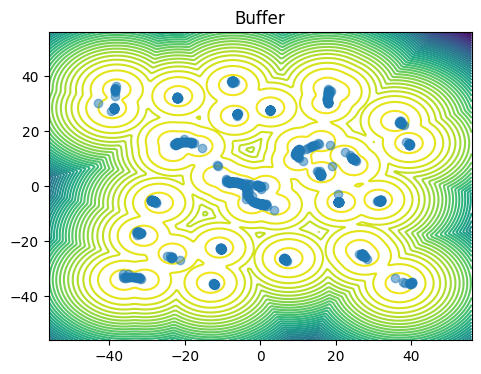

  2%|▏         | 2/100 [00:28<23:38, 14.48s/it]

ESS 0.970208, Triggering resampling
ESS 0.978886, Triggering resampling
ESS 0.979899, Triggering resampling
ESS 0.979681, Triggering resampling
ESS 0.979534, Triggering resampling
ESS 0.979660, Triggering resampling
ESS 0.979301, Triggering resampling
ESS 0.979855, Triggering resampling
ESS 0.979929, Triggering resampling
ESS 0.979779, Triggering resampling
ESS 0.978864, Triggering resampling
ESS 0.979730, Triggering resampling
Epoch 2 | Time 0.000000 | Loss 3.259387
Epoch 2 | Time 0.003906 | Loss 1.330474
Epoch 2 | Time 0.007812 | Loss 0.814031
Epoch 2 | Time 0.011719 | Loss 0.594179
Epoch 2 | Time 0.015625 | Loss 0.496407
Epoch 2 | Time 0.019531 | Loss 0.388723
Epoch 2 | Time 0.023438 | Loss 0.358047
Epoch 2 | Time 0.027344 | Loss 0.310096
Epoch 2 | Time 0.031250 | Loss 0.274716
Epoch 2 | Time 0.035156 | Loss 0.259046
Epoch 2 | Time 0.039062 | Loss 0.242033
Epoch 2 | Time 0.042969 | Loss 0.221920
Epoch 2 | Time 0.046875 | Loss 0.219033
Epoch 2 | Time 0.050781 | Loss 0.211117
Epoch 2 

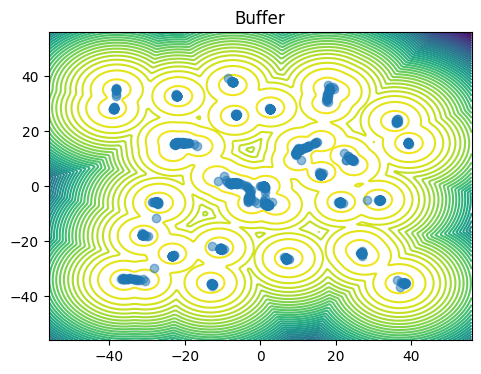

  3%|▎         | 3/100 [00:41<22:03, 13.64s/it]

ESS 0.976209, Triggering resampling
ESS 0.976172, Triggering resampling
ESS 0.979791, Triggering resampling
ESS 0.979944, Triggering resampling
ESS 0.979739, Triggering resampling
ESS 0.978944, Triggering resampling
ESS 0.979626, Triggering resampling
ESS 0.979868, Triggering resampling
ESS 0.979999, Triggering resampling
ESS 0.979599, Triggering resampling
ESS 0.979728, Triggering resampling
Epoch 3 | Time 0.000000 | Loss 2.097471
Epoch 3 | Time 0.003906 | Loss 1.113028
Epoch 3 | Time 0.007812 | Loss 0.629130
Epoch 3 | Time 0.011719 | Loss 0.545634
Epoch 3 | Time 0.015625 | Loss 0.479050
Epoch 3 | Time 0.019531 | Loss 0.396915
Epoch 3 | Time 0.023438 | Loss 0.332542
Epoch 3 | Time 0.027344 | Loss 0.315866
Epoch 3 | Time 0.031250 | Loss 0.287594
Epoch 3 | Time 0.035156 | Loss 0.278985
Epoch 3 | Time 0.039062 | Loss 0.251313
Epoch 3 | Time 0.042969 | Loss 0.246883
Epoch 3 | Time 0.046875 | Loss 0.231965
Epoch 3 | Time 0.050781 | Loss 0.206738
Epoch 3 | Time 0.054688 | Loss 0.204870
Epoc

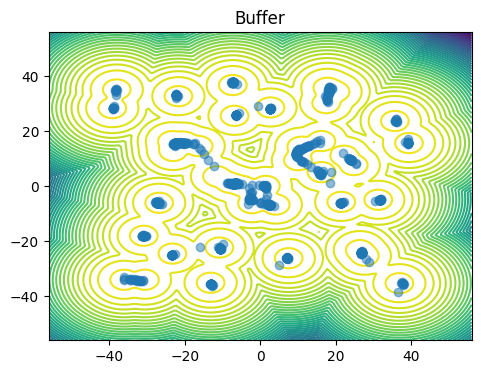

  4%|▍         | 4/100 [00:55<21:51, 13.66s/it]

ESS 0.970253, Triggering resampling
ESS 0.976950, Triggering resampling
ESS 0.979797, Triggering resampling
ESS 0.978929, Triggering resampling
ESS 0.979756, Triggering resampling
ESS 0.979924, Triggering resampling
ESS 0.979858, Triggering resampling
ESS 0.979349, Triggering resampling
ESS 0.979754, Triggering resampling
ESS 0.979679, Triggering resampling


  4%|▍         | 4/100 [01:02<24:59, 15.62s/it]


KeyboardInterrupt: 

In [9]:
# Constants
epsilon = 1e-6
vectorfield = MyMLPDualOutput(hidden_size=128, hidden_layers=3, emb_size=128).to(device)
optimizer = Adam(vectorfield.parameters(), lr=1e-3)
reverse_ode = ReverseODE(vectorfield, noise_schedule, prior=prior, target=target, clipper=clipper, schedule=schedule, resampling_method='systematic')
num_samples = 1_024
outer_epochs = 100
inner_epochs = 2
beta = 1.0
lagrange_multiplier = 1.0
pts = None
all_on_cuda = all(param.is_cuda for param in vectorfield.parameters())
print(f"All parameters on CUDA: {all_on_cuda}")
not_first_epoch = False

for epoch in tqdm(range(outer_epochs)):
    target = GMM(dimensionality=2,
             n_mixes=40,
             loc_scaling= 40,
             log_var_scaling=1.0,
             device=device,
             should_unnormalize=True)

    total_loss = 0.
    start_time = torch.tensor(0.0).to(device)
    delta = t_end - start_time
    num_integration_steps = int(torch.abs(delta) / dt)
    times = torch.linspace(start_time, t_end, num_integration_steps + 1)[:-1]
    indices = torch.arange(times.shape[0]).to(device)
    
    langevin_sde = LangevinSDE(beta=beta, prior=prior, target=target, vel=vectorfield, clipper=clipper, schedule=schedule)
    x_gen, weights = langevin_sde.sample(x0=None, dt=dt, end_time=t_end, device=device, num_samples=1_024, resample=not_first_epoch)
    
    if not_first_epoch:
          pts_list = torch.softmax(weights, dim=1)
    for i, t in zip(indices, times):
            optimizer.zero_grad()
            x = x_gen[i].to(device).detach()
            if not_first_epoch:
                  pts = pts_list[i].detach()
            t = t.to(device).detach()
            loss = compute_wfr_loss(pts, x, t, schedule, target, prior, vectorfield,
                                    lagrange_multiplier, compute_kinetic_energy=True)
            loss = loss.mean()
            total_loss += loss.item()
            loss.backward()
            optimizer.step()

            print("Epoch %d | Time %f | Loss %f" % (epoch, t.item(), loss.item()))

    # Generate samples using the network
    samples = generate_samples_ode(reverse_ode, 1_024, resample=True)
    samples_energy = target(samples)
    target.get_dataset_fig(target.unnormalize(samples))
    plt.show()
    not_first_epoch = True


In [ ]:
target = GMM(dimensionality=2,
            n_mixes=40,
            loc_scaling= 40,
            log_var_scaling=1.0,
            device=device,
            should_unnormalize=True)
langevin_sde = LangevinSDE(beta=beta, prior=prior, target=target, clipper=clipper, vel=vectorfield, schedule=schedule, resample_threshold=0.98)

dt = torch.tensor(1.0 / 512).to(device)
t_init,t_end = torch.tensor(0.0).to(device), torch.tensor(1.0).to(device)
samples = langevin_sde.sample(x0=None, dt=dt, end_time=t_end, device=device, num_samples=1_000, compute_weight=True)
samples_energy = target(samples[-1])
target.get_dataset_fig(target.unnormalize(samples[-1]))
plt.show()